In [1]:
import pandas as pd
url = 'https://raw.githubusercontent.com/kanetkar/LULML/refs/heads/main/ch11/students.csv'
df = pd.read_csv(url)
print(df.head( ))


           IQ      CGPA  Placed
0  116.521863  7.839804       1
1  111.114991  7.230805       1
2  109.839861  7.253657       1
3   99.772056  5.960763       0
4  111.693979  9.576941       1


In [3]:
from sklearn.model_selection import train_test_split

# features and label
X = df[['IQ', 'CGPA']]  # Inputs
y = df['Placed']           # Output

# split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)


In [4]:
from sklearn.linear_model import LogisticRegression

# create model
model = LogisticRegression( )

# train it
model.fit(X_train, y_train)


LogisticRegression()

In [5]:
from sklearn.metrics import accuracy_score

# make predictions
y_pred = model.predict(X_test)

# measure accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Model Accuracy on Test Set: {acc * 100:.2f}%")


Model Accuracy on Test Set: 95.00%


In [6]:
from sklearn.datasets import make_classification
import pandas as pd
import numpy as np

# generate data
X, y = make_classification(n_samples = 500, n_features = 100,
n_informative = 5,n_redundant = 0, n_classes = 2, random_state = 42)


In [7]:
# split into training (80%) and test (20%)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,
								    test_size = 0.2, random_state = 1)


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# train model with no regularization (C is very large)
model_no_reg = LogisticRegression(penalty = 'l2', C = 1e10,
                                  max_iter = 1000)
model_no_reg.fit(X_train, y_train)

# evaluate
train_acc = accuracy_score(y_train, model_no_reg.predict(X_train))
test_acc = accuracy_score(y_test, model_no_reg.predict(X_test))
print(f"Train Accuracy (no regularization): {train_acc * 100:.2f}%")
print(f"Test Accuracy (no regularization): {test_acc * 100:.2f}%")


Train Accuracy (no regularization): 93.25%
Test Accuracy (no regularization): 69.00%


In [9]:
# Elastic Net Regularization
model_en = LogisticRegression(penalty = 'elasticnet', solver = 'saga',
				C = 0.1,  l1_ratio = 0.5, max_iter = 1000)
model_en.fit(X_train, y_train)

# accuracy
train_acc_en = accuracy_score(y_train, model_en.predict(X_train))
test_acc_en = accuracy_score(y_test, model_en.predict(X_test))

print(f"Elastic Net - Train Accuracy: {train_acc_en * 100:.2f}%")
print(f"Elastic Net - Test Accuracy: {test_acc_en * 100:.2f}%")


Elastic Net - Train Accuracy: 88.00%
Elastic Net - Test Accuracy: 85.00%


In [11]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
# Generate dataset
X, y = make_moons(n_samples = 300, noise = 0.25, random_state = 0)

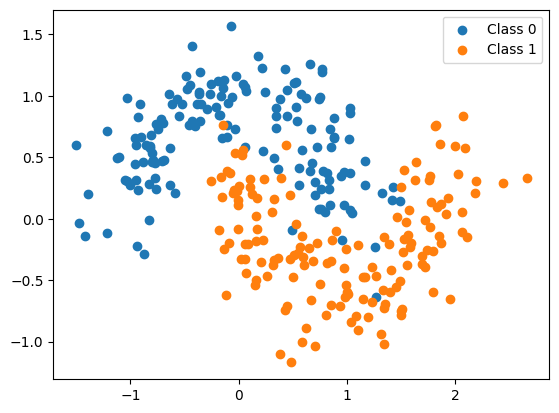

In [12]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

# Generate dataset
X, y = make_moons(n_samples=300, noise=0.25, random_state=0)

# Visualize
plt.scatter(X[y==0][:, 0], X[y==0][:, 1], label='Class 0')
plt.scatter(X[y==1][:, 0], X[y==1][:, 1], label='Class 1')
plt.legend()
plt.show()

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2,
								    random_state = 42)
model = LogisticRegression( )
model.fit(X_train, y_train)

# accuracy
train_acc = accuracy_score(y_train, model.predict(X_train))
test_acc = accuracy_score(y_test, model.predict(X_test))
print(f"Train Accuracy: {train_acc * 100:.2f}%")
print(f"Test Accuracy: {test_acc * 100:.2f}%")


Train Accuracy: 82.08%
Test Accuracy: 85.00%


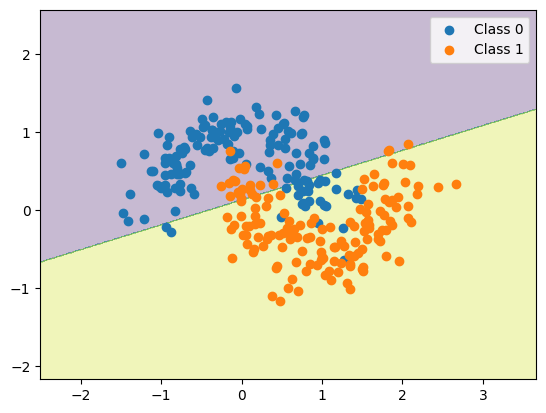

In [14]:
import numpy as np

def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                         np.linspace(y_min, y_max, 500))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[y==0][:, 0], X[y==0][:, 1], label='Class 0')
    plt.scatter(X[y==1][:, 0], X[y==1][:, 1], label='Class 1')
    plt.legend()
    plt.show()

plot_decision_boundary(model, X, y)

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

# pipeline: Polynomial transformation + Logistic Regression
model = Pipeline([
    ('poly', PolynomialFeatures(degree = 3)),
    ('log_reg', LogisticRegression())])
model.fit(X_train, y_train)

# accuracy
train_acc = accuracy_score(y_train, model.predict(X_train))
test_acc = accuracy_score(y_test, model.predict(X_test))
print(f"Train Accuracy: {train_acc * 100:.2f}%")
print(f"Test Accuracy: {test_acc * 100:.2f}%")


Train Accuracy: 94.58%
Test Accuracy: 91.67%


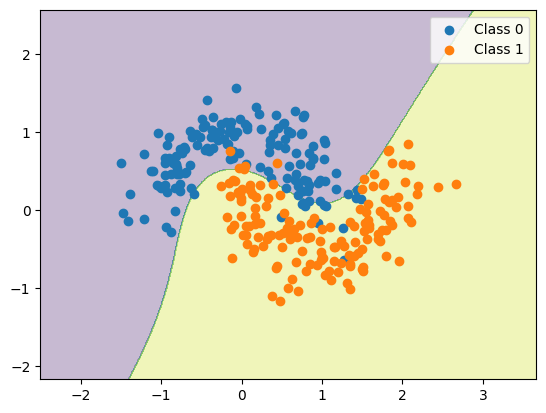

In [16]:
import numpy as np

def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                         np.linspace(y_min, y_max, 500))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[y==0][:, 0], X[y==0][:, 1], label='Class 0')
    plt.scatter(X[y==1][:, 0], X[y==1][:, 1], label='Class 1')
    plt.legend()
    plt.show()

plot_decision_boundary(model, X, y)